In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [ ]:
#@title MIT License
#
# Copyright (c) 2017 François Chollet
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

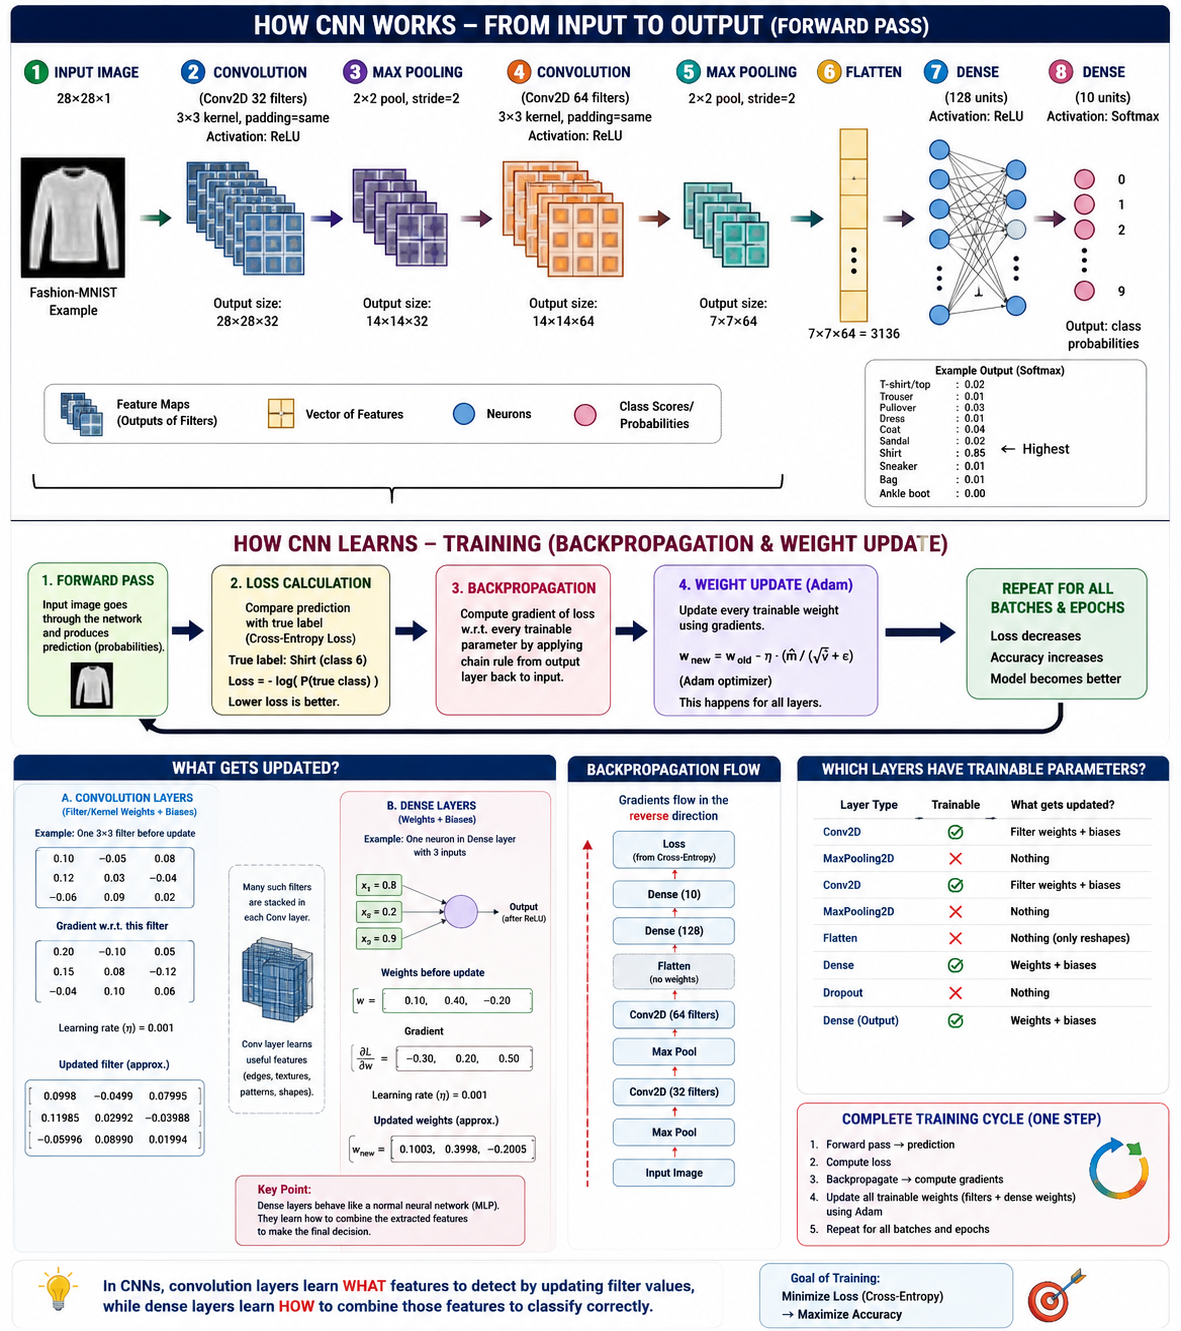

## 1. Import libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Load Fashion-MNIST

Fashion-MNIST contains:

- 60,000 training images
- 10,000 test images
- image size: 28 × 28
- 10 clothing classes


In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Original pixel range:", x_train.min(), "to", x_train.max())


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Original pixel range: 0 to 255


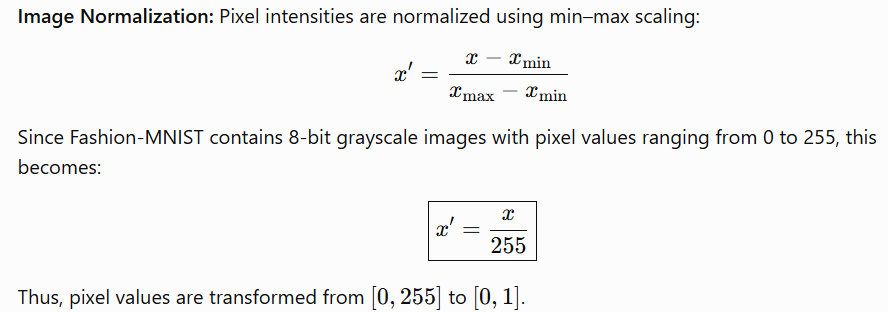

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape after channel dimension:", x_train.shape)
print("Test shape after channel dimension:", x_test.shape)
print("Normalized pixel range:", x_train.min(), "to", x_train.max())


Training shape after channel dimension: (60000, 28, 28, 1)
Test shape after channel dimension: (10000, 28, 28, 1)
Normalized pixel range: 0.0 to 1.0


## 4. Visualize examples


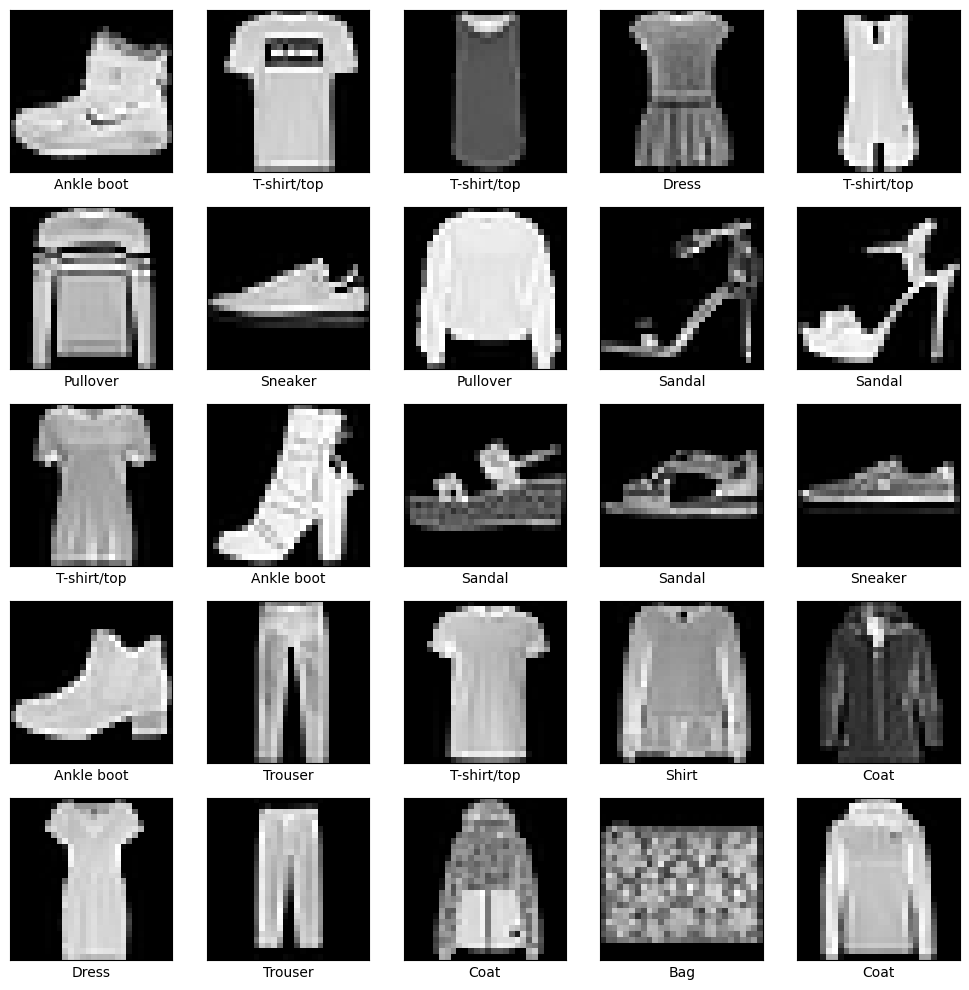

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i, :, :, 0], cmap="gray")
    plt.xlabel(class_names[y_train[i]])

plt.tight_layout()
plt.show()


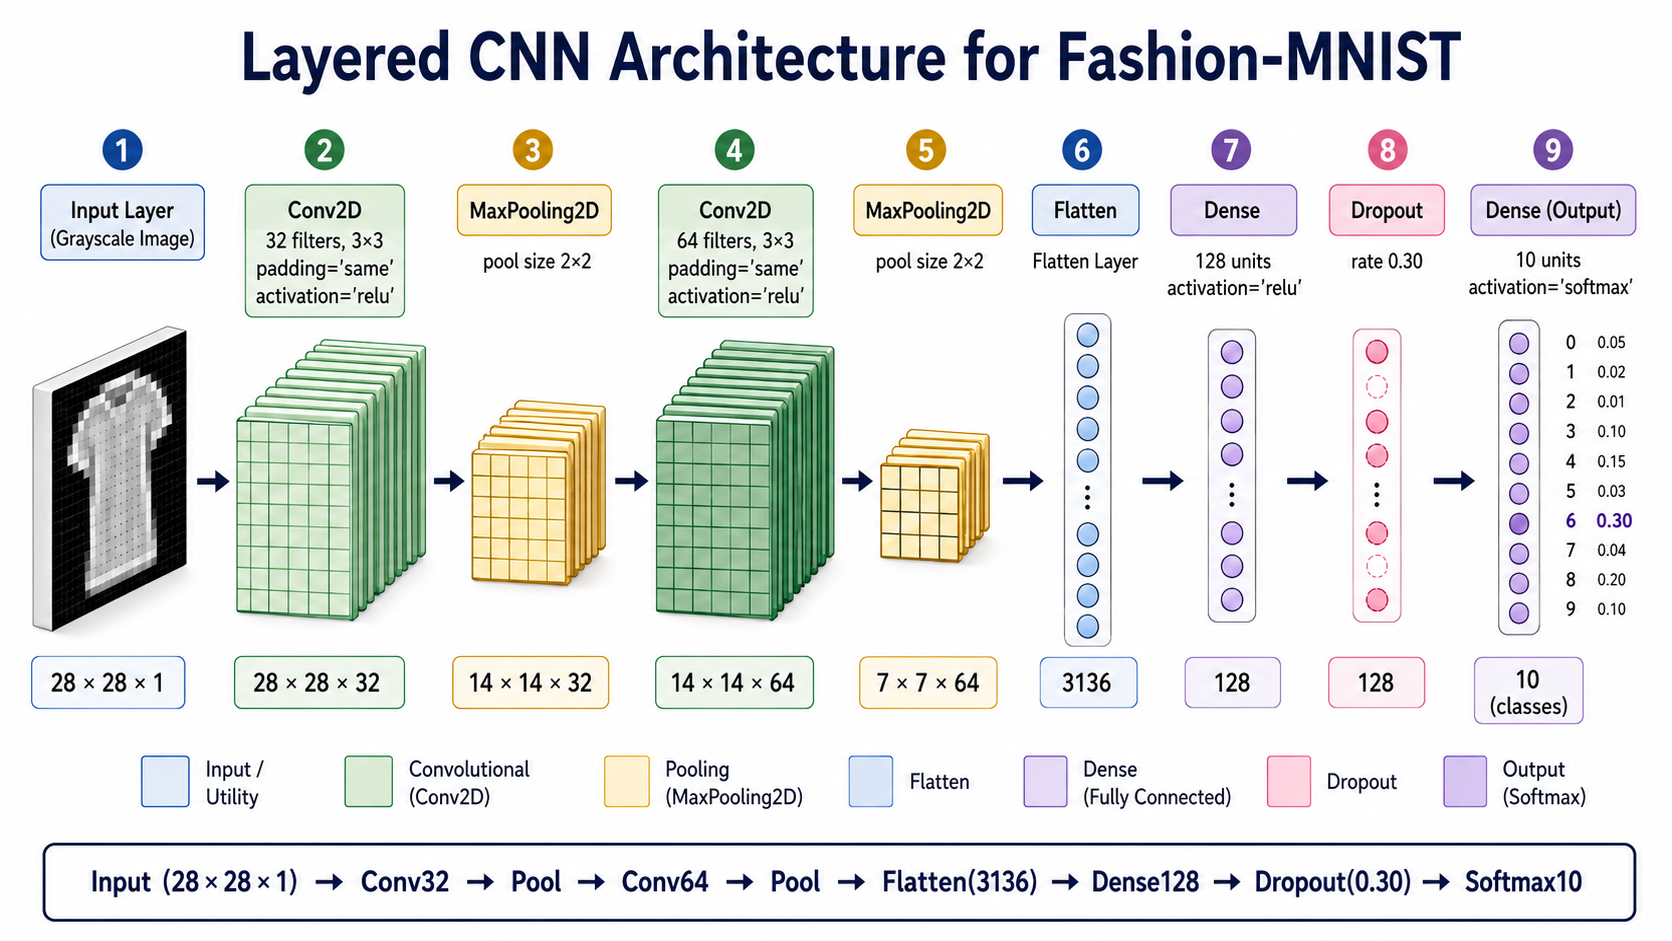

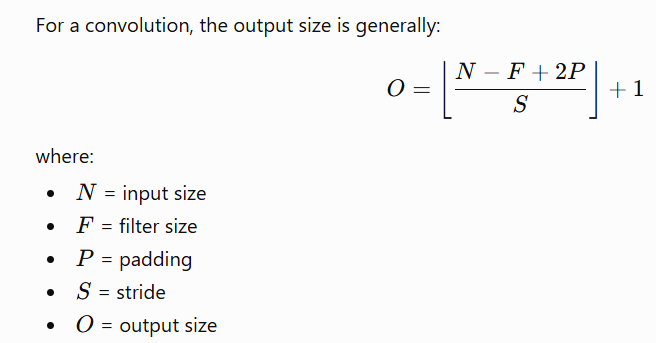

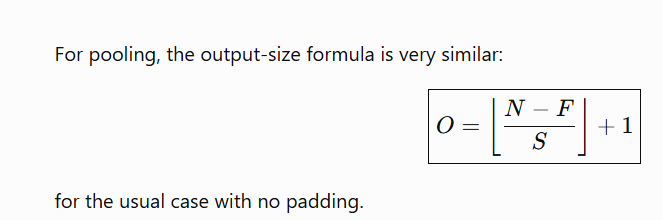

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile the model

Because labels are integer class indices `0...9`, we use:

\[
\text{SparseCategoricalCrossentropy}
\]

The final Softmax layer returns probabilities for the 10 classes.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)


## 8. Train the model — THIS STEP MUST RUN

This was the missing step in the uploaded notebook.

The model is trained for up to 12 epochs. `EarlyStopping` restores the best validation weights if validation loss stops improving.

**Do not evaluate the model before this cell has finished.**


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=12,
    validation_split=0.10,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed.")
print("Best validation accuracy:",
      max(history.history["val_accuracy"]))


Epoch 1/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8274 - loss: 0.4826 - val_accuracy: 0.8758 - val_loss: 0.3357
Epoch 2/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8855 - loss: 0.3167 - val_accuracy: 0.8902 - val_loss: 0.3008
Epoch 3/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9014 - loss: 0.2716 - val_accuracy: 0.9048 - val_loss: 0.2585
Epoch 4/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9129 - loss: 0.2388 - val_accuracy: 0.9052 - val_loss: 0.2624
Epoch 5/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9199 - loss: 0.2159 - val_accuracy: 0.9167 - val_loss: 0.2303
Epoch 6/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9281 - loss: 0.1955 - val_accuracy: 0.9188 - val_loss: 0.2259
Epoch 7/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9348 - loss: 0.1774 - val_accuracy: 0.9175 - val_loss: 0.2371
Epoch 8/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9410 - loss: 0.1597 - val_accuracy: 0

## 9. Plot training and validation accuracy

A healthy run should show training and validation accuracy rising well above chance level.


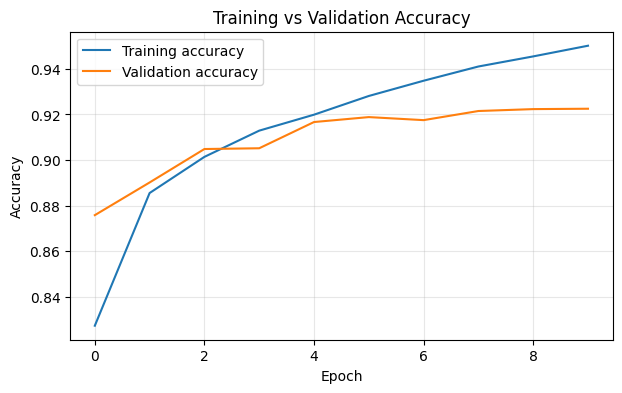

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 10. Plot training and validation loss


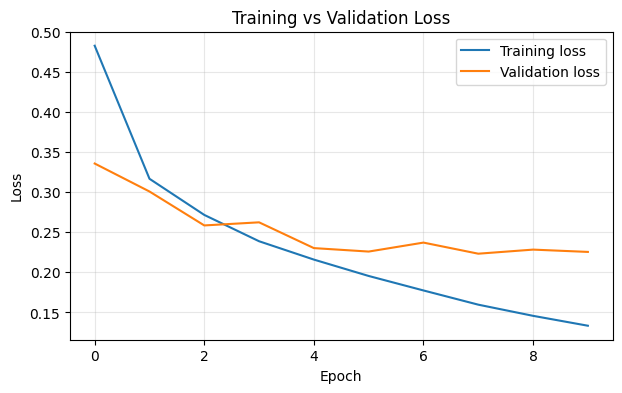

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11. Final evaluation on the untouched test set

The test set is used only after training is complete.


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    batch_size=64,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy (%): {100 * test_accuracy:.2f}%")


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9184 - loss: 0.2418
Test loss: 0.2418
Test accuracy: 0.9184
Test accuracy (%): 91.84%


## 12. Sanity check: inspect prediction probabilities

For a trained model, the probability vector should usually **not** be nearly uniform across all 10 classes.


In [ ]:
predictions = model.predict(x_test[:32], verbose=0)

print("Prediction shape:", predictions.shape)
print("\nFirst probability vector:")
print(np.round(predictions[0], 4))
print("\nSum:", predictions[0].sum())

predicted_class = int(np.argmax(predictions[0]))
true_class = int(y_test[0])

print("\nPredicted:", predicted_class, "-", class_names[predicted_class])
print("True:     ", true_class, "-", class_names[true_class])
print("Confidence:", f"{100*np.max(predictions[0]):.2f}%")


Prediction shape: (32, 10)

First probability vector:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

Sum: 1.0

Predicted: 9 - Ankle boot
True:      9 - Ankle boot
Confidence: 100.00%


## 13. Visualize predictions


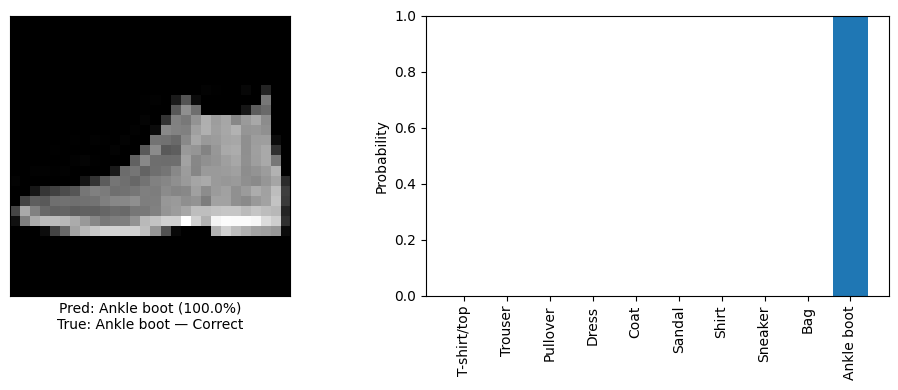

In [ ]:
def plot_prediction(index, predictions_array, true_labels, images):
    probs = predictions_array[index]
    true_label = int(true_labels[index])
    predicted_label = int(np.argmax(probs))

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(images[index, :, :, 0], cmap="gray")
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    status = "Correct" if predicted_label == true_label else "Incorrect"
    plt.xlabel(
        f"Pred: {class_names[predicted_label]} "
        f"({100*np.max(probs):.1f}%)\n"
        f"True: {class_names[true_label]} — {status}"
    )

    plt.subplot(1, 2, 2)
    plt.bar(range(10), probs)
    plt.xticks(range(10), class_names, rotation=90)
    plt.ylim([0, 1])
    plt.ylabel("Probability")
    plt.tight_layout()
    plt.show()

plot_prediction(0, predictions, y_test[:32], x_test[:32])


## 14. Show multiple test predictions


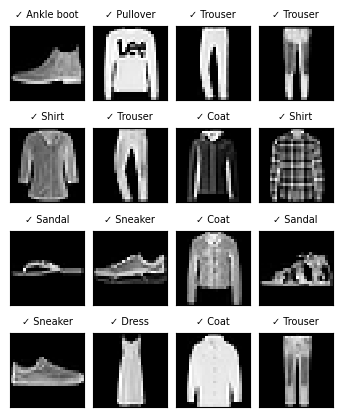

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fashion-MNIST original size = 28 × 28
# Display each image at 3× native resolution = 84 × 84 pixels
scale = 3
image_pixels = 28 * scale

dpi = 100

# 4 images across = 4 × 84 pixels
fig_width = (4 * image_pixels) / dpi

# Extra vertical space for titles
fig_height = fig_width + 0.8

fig, axes = plt.subplots(
    4, 4,
    figsize=(fig_width, fig_height),
    dpi=dpi
)

for i, ax in enumerate(axes.flat):

    predicted_label = int(np.argmax(predictions[i]))
    true_label = int(y_test[i])

    ax.imshow(
        x_test[i, :, :, 0],
        cmap="gray",
        interpolation="none",   # no smoothing
        resample=False,         # no resampling
        vmin=0,
        vmax=1
    )

    ax.set_xticks([])
    ax.set_yticks([])

    if predicted_label == true_label:
        ax.set_title(
            f"✓ {class_names[predicted_label]}",
            fontsize=7
        )
    else:
        ax.set_title(
            f"✗ {class_names[predicted_label]}\n"
            f"True: {class_names[true_label]}",
            fontsize=7
        )

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.94,
    bottom=0.02,
    wspace=0.12,
    hspace=0.35
)

plt.show()